# MetaSearch Engine for IPO

<b>The purpose of this notebook is to create a 'SinglePointNews' meta-search engine for a company that has filed for IPO

<b>Import the libraries

In [32]:
#Import required libraries
import re
import string
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
import datetime
import urllib
import datetime
from bs4 import BeautifulSoup
from itertools import islice
from dateutil.relativedelta import relativedelta
from datetime import timedelta
from datetime import datetime
import datetime


In [33]:
ipo_company_name = input("enter the company name : ")
%store ipo_company_name

#del ipo_compay_name

Stored 'ipo_company_name' (str)


In [34]:
ipo_company_name

'Behari Lal Engineering'

In [35]:
import os
dir_name=ipo_company_name

if not os.path.exists(dir_name):
    os.makedirs(dir_name)

### Task 1: Document Extraction from a search engine

<b> 1. Document content as only its summary or snippet , document title, Date/Time of the news is extracted. Only the business category is considered as the IPO news falls under business <br>
<b> 2. Google and Bing search engines are considered 

In [36]:
class MSE(object):
    
    def __init__(self, number_of_results=None, l_from_date=None, l_to_date=None):
        
        assert isinstance(number_of_results, int), 'Number of results must be an integer'
        if number_of_results is None:
            self.number_of_results = 20
        else:
            self.number_of_results = number_of_results
        
        self.dt_format = '%d/%m/%Y'
        
        if l_to_date is None:
            self.to_date_obj = datetime.datetime.now()
        else:
            self.to_date_obj = datetime.datetime.strptime(str(l_to_date), self.dt_format)
            self.to_date_obj = datetime.datetime.combine(self.to_date_obj.date(), datetime.time(23, 59, 59))

        if l_from_date is None:
            five_days_ago = (datetime.datetime.now() - timedelta(days=5))
            self.from_date_obj = datetime.datetime.combine(five_days_ago.date(), datetime.time(0, 0, 0))
        else:
            self.from_date_obj = datetime.datetime.strptime(str(l_from_date), self.dt_format)

        self.search_engine = 'Google'
        print("Args: " + str(self.number_of_results) + ", " + str(self.from_date_obj) + ", " + str(self.to_date_obj))

    def parse_google_html(self,category,html):
        
        soup = BeautifulSoup(html, 'html.parser')
        found_result = []
        position_in_search_result = 1
        result_block = soup.find_all('c-wiz', class_='PO9Zff')
        result_range = min(len(result_block), self.number_of_results)
        
        for result in result_block:

            link = result.find('a', class_='JtKRv')
            #Extract the title
            title = result.find('a', class_='JtKRv')
            snippet = None
            datetime_tag = result.find('time')
            datetime_str = datetime_tag['datetime']
            datetime_obj = datetime.datetime.strptime(str(datetime_str), '%Y-%m-%dT%H:%M:%SZ')

            #if link and title:
            if self.from_date_obj < datetime_obj < self.to_date_obj:
                if title:
                    link = link['href']
                    title = title.get_text()
                    if snippet:
                        snippet = snippet.get_text()
                        #print('snippet', snippet)
                    
                    #DateTime = re.split("T",time['datetime'])[0]
                    #print('DT', time['datetime'])
                    #print('G Categoty:', category)

                    found_result.append({
                                        'engine' : 'Google',
                                        'rank': position_in_search_result,
                                        'docid': 'G'+str(position_in_search_result),
                                        'category': category,
                                        'title': title,
                                        'snippet': snippet,                                    
                                        'DateTime': str(datetime_obj)
                                    }) 
                    position_in_search_result += 1
            if position_in_search_result > self.number_of_results:
                break
        print("Length of found_result" + str(len(found_result)))              
        return found_result

    def parse_bing_html(self, category, html):
        
        soup = BeautifulSoup(html, 'html.parser')
        found_result = []
        position_in_search_result = 1

        result_block = soup.find_all('div', class_='news-card')
        print(len(result_block))
        
        result_range = min(len(result_block), self.number_of_results)
        print('Result range : ' + str(result_range))

        #for index, result in zip(range(result_range), result_block):
        for result in result_block:

            title = result.find('a', class_='title')

            snippet = result.find('div', class_='snippet')
            
            datetime_tag = result.find('span', attrs={'aria-label': True})
            datetime_rel = datetime_tag['aria-label']

            try:
                datetime_obj = self.getpastdate(str(datetime_rel))
            except:
                continue

            
            if self.from_date_obj < datetime_obj < self.to_date_obj:

                #if link and title:
                if title:
              
                    title = title.get_text()
                    if snippet:
                        snippet = snippet.get_text()

                    found_result.append({
                                        'engine' : 'Google',
                                        'rank': position_in_search_result,
                                        'docid': 'B'+str(position_in_search_result),
                                        'title': title,
                                        'snippet': snippet,
                                        'category': category,
                                        'date_time' : str(datetime_obj)
                                    }) 
                    position_in_search_result += 1
            if position_in_search_result > self.number_of_results:
                break
        print("Length of found_result" + str(len(found_result)))
        return found_result
      
    def google_news(self, category, query, language_code = 'en'):
        search_url = self.get_search_query(category, query, 'en', 'Google')
        response = response_text = self.execute_search(search_url)
        parsed_result = self.parse_google_html(category, response)
        return parsed_result

    def bing_news(self, category, query, language_code = 'en-us'):
        search_url = self.get_search_query(category, query, language_code, 'Bing')
        response = response_text = self.execute_search(search_url)
        parsed_result = self.parse_bing_html(category, response)            
        return parsed_result

    def execute_search(self, search_url):
        USER_AGENT = {'User-Agent':'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/61.0.3163.100 Safari/537.36'}
        parsed_result = dict()
        response = ''
        response = requests.get(search_url, headers=USER_AGENT, verify=False)
        response.raise_for_status()
        return response.text

    def get_search_query(self, category, query, language, search_engine='Google'):
        search_url = ''
        if search_engine == 'Google':
            params = { 'q' : category + ' ' + query, 'hl' : language}
            search_url = "https://news.google.com/search?" + urllib.parse.urlencode(params)
        elif search_engine == 'Bing':
            params = { 'q' : category + ' ' + query, 'setlang' : language, 'count' : '100'}
            search_url = "https://www.bing.com/news/search?" + urllib.parse.urlencode(params)
        print("Search url : " + search_url)        
        return search_url
   
   
    def getpastdate(self, str_days_ago):
        TODAY = datetime.datetime.today()
        splitted = str_days_ago.split()
        if len(splitted) == 1 and splitted[0].lower() == 'today':
            return TODAY
        elif len(splitted) == 1 and splitted[0].lower() == 'yesterday':
            dt_obj = TODAY - relativedelta(days=1)
            return dt_obj
        elif splitted[1].lower() in ['minute', 'minutes', 'min', 'mins', 'm']:
            dt_obj = datetime.datetime.now() - relativedelta(minutes=int(splitted[0]))
            return dt_obj
        elif splitted[1].lower() in ['hour', 'hours', 'hr', 'hrs', 'h']:
            dt_obj = datetime.datetime.now() - relativedelta(hours=int(splitted[0]))
            return dt_obj
        elif splitted[1].lower() in ['day', 'days', 'd']:
            dt_obj = TODAY - relativedelta(days=int(splitted[0]))
            return dt_obj
        elif splitted[1].lower() in ['wk', 'wks', 'week', 'weeks', 'w']:
            dt_obj = TODAY - relativedelta(weeks=int(splitted[0]))
            return dt_obj
        elif splitted[1].lower() in ['mon', 'mons', 'month', 'months', 'm']:
            dt_obj = TODAY - relativedelta(months=int(splitted[0]))
            return dt_obj
        elif splitted[1].lower() in ['yrs', 'yr', 'years', 'year', 'y']:
            date = TODAY - relativedelta(years=int(splitted[0]))
            return dt_obj
        else:
            return datetime.datetime.strptime(str_days_ago, self.dt_format)
    
    def clean_text(self, text, title= False):
        if str(text) == 'nan' and type(text) != 'str':
            return ""
    
        if title:
            text = "".join([word for word in text if word not in string.punctuation])
        else:
            text = "".join([word.lower() for word in text if word not in string.punctuation])
        tokens = re.split('\W+', text)
        text = " ".join([word for word in tokens if word.isalpha()])
        return text  


<b> Top 50 news content starting from today in the last 30 days is extacted

In [37]:
top_n_result = 100
from pickle import NONE
#l_from_date='25/10/2020'
#l_to_date='02/01/2021'

company_name = ipo_company_name + '_IPO'
print("Company name ; ", company_name)


l_from_date = (datetime.date.today() - datetime.timedelta(days=90))
l_to_date = datetime.date.today()
print("from date : ",l_from_date)
print("l_to_date : ",l_to_date)

metasearchengine = MSE(top_n_result, None, None)
google_results_business = metasearchengine.google_news('', ipo_company_name, 'en')
bing_results_business = metasearchengine.bing_news('', ipo_company_name, 'en-us')

Company name ;  Behari Lal Engineering_IPO
from date :  2026-05-10
l_to_date :  2026-08-08
Args: 100, 2026-08-03 00:00:00, 2026-08-08 20:26:16.779497
Search url : https://news.google.com/search?q=+Behari+Lal+Engineering&hl=en


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'news.google.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'news.google.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


Length of found_result21
Search url : https://www.bing.com/news/search?q=+Behari+Lal+Engineering&setlang=en-us&count=100


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'www.bing.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


2
Result range : 2
Length of found_result2


In [38]:
# import os

# google_cols = ['engine', 'rank', 'docid', 'category', 'title', 'snippet', 'DateTime']
# bing_cols = ['engine', 'rank', 'docid', 'title', 'snippet', 'category', 'date_time']

# def load_fallback_df(filename, default_cols, is_bing=False, category='Technology'):
#     df = None
#     # Try loading from current directory if exists and is not empty
#     if os.path.exists(filename):
#         try:
#             temp_df = pd.read_csv(filename, sep='\t')
#             if len(temp_df) > 0:
#                 df = temp_df
#         except Exception:
#             pass
            
#     # If current directory file is missing or empty, search sibling directory
#     if df is None or len(df) == 0:
#         sibling_path = os.path.join('..', company_name, filename)
#         if os.path.exists(sibling_path):
#             try:
#                 temp_df = pd.read_csv(sibling_path, sep='\t')
#                 if len(temp_df) > 0:
#                     df = temp_df
#                     # Restore the non-empty file to current directory
#                     df.to_csv(filename, sep='\t', index=False)
#                     print(f"Restored non-empty data from {sibling_path} to {filename}")
#             except Exception as e:
#                 print(f"Error reading sibling fallback {sibling_path}: {e}")
                
#     if df is not None and len(df) > 0:
#         if 'title_snippet' in df.columns:
#             df['engine'] = 'Bing' if is_bing else 'Google'
#             df['rank'] = list(range(1, len(df) + 1))
#             df['category'] = category
#             df['title'] = df['title_snippet'].apply(lambda x: str(x).split(' ')[0] if pd.notna(x) else '')
#             df['snippet'] = df['title_snippet'].apply(lambda x: ' '.join(str(x).split(' ')[1:]) if pd.notna(x) else '')
#             if is_bing:
#                 df['date_time'] = '2021-01-01 00:00:00'
#             else:
#                 df['DateTime'] = '2021-01-01 00:00:00'
#             return df
            
#     return pd.DataFrame([], columns=default_cols)

# if not google_results_business:
#     pd_google_results_business = load_fallback_df(company_name+'._google_business.txt', google_cols, is_bing=False, category='Business')
# else:
#     pd_google_results_business = pd.DataFrame(google_results_business, columns=google_cols)

# if not bing_results_business:
#     pd_bing_results_business = load_fallback_df(company_name+'._bing_business.txt', bing_cols, is_bing=True, category='Business')
# else:
#     pd_bing_results_business = pd.DataFrame(bing_results_business, columns=bing_cols)

In [39]:
pd_google_results_business = pd.DataFrame(google_results_business, columns=['engine', 'rank', 'docid', 'title', 'snippet', 'DateTime'])
pd_bing_results_business = pd.DataFrame(bing_results_business, columns=['engine', 'rank', 'docid', 'title', 'snippet', 'date_time'])


<b> Top 5 google results

In [40]:
pd_google_results_business.head()

,engine,rank,docid,title,snippet,DateTime
0,Google,1,G1,Behari Lal Engineering IPO Opens Aug 12: Price...,None,2026-08-07 05:44:55
1,Google,2,G2,Behari Lal Engineering fixes price band at Rs ...,None,2026-08-07 19:08:21
2,Google,3,G3,"IPO GMPs: Dhoot Transmission, Molbio Diagnosti...",None,2026-08-08 08:59:13
3,Google,4,G4,Behari Lal Engineering Sets Rs 271-285 Price B...,None,2026-08-08 11:16:35
4,Google,5,G5,Behari Lal Engineering Ltd. IPO,None,2026-08-07 18:58:00


<b> Top 5 bing results

In [41]:
pd_bing_results_business.head()

,engine,rank,docid,title,snippet,date_time
0,Google,1,B1,"IPO GMPs: Dhoot Transmission, Molbio Diagnosti...",These five mainboard upcoming IPOs are going t...,2026-08-08 15:26:18.413197
1,Google,2,B2,Upcoming IPOs: Dhoot Transmission to Shiprocke...,Dhoot Transmission and Molbio Diagnostics will...,2026-08-08 17:26:18.413422


<b> Concatenate Title and News snippet

In [42]:
pd_google_results_business['title_snippet'] = pd_google_results_business['title'].fillna('')+' '+pd_google_results_business['snippet'].fillna('')
pd_bing_results_business['title_snippet'] = pd_bing_results_business['title'].fillna('')+' '+pd_bing_results_business['snippet'].fillna('')


<b> Normalize and clean the above concatenated text

In [43]:
#Normalize and clean the text
pd_google_results_business['title_snippet'] = pd_google_results_business['title_snippet'].apply(lambda x: metasearchengine.clean_text(x))
pd_bing_results_business['title_snippet'] = pd_bing_results_business['title_snippet'].apply(lambda x: metasearchengine.clean_text(x))

<b> Select top 50 results from both the search engines

In [44]:
#Select top n results
pd_google_results_business = pd_google_results_business.loc[:top_n_result-1,:]
pd_bing_results_business = pd_bing_results_business.loc[:top_n_result-1,:]

In [45]:
google_result_business = pd_google_results_business.loc[:,['docid', 'title_snippet']]
bing_result_business = pd_bing_results_business.loc[:,['docid', 'title_snippet']]

In [46]:
google_result_business.head()

,docid,title_snippet
0,G1,behari lal engineering ipo opens aug price rs
1,G2,behari lal engineering fixes price band at rs
2,G3,ipo gmps dhoot transmission molbio diagnostics...
3,G4,behari lal engineering sets rs price band for ...
4,G5,behari lal engineering ltd ipo


In [47]:
bing_result_business.head()

,docid,title_snippet
0,B1,ipo gmps dhoot transmission molbio diagnostics...
1,B2,upcoming ipos dhoot transmission to shiprocket...


<b> Write the results to separate files for each search engine

In [48]:
query = company_name
google_result_business.to_csv(dir_name+"/"+query+'_google_business.txt', sep='\t', index=False)
bing_result_business.to_csv(dir_name+"/"+query+'_bing_business.txt', sep='\t', index=False)

# Task 2: Aggregated News Collection

<b>1. Concatenate the search results of both the search engines <br>
<b>2. Remove the duplicates after concatenation  <br>
<b>3. Create a new ranking after the duplicates are removed.<br>
<b>4. Aggregate the news collection

In [49]:
#Concatenate both the result
search_result = pd.concat([pd_google_results_business, pd_bing_results_business], ignore_index=True)

#Remove the duplicate results using title column
search_result = search_result[~search_result['title'].duplicated()]

print('%d total search results after removing the duplicates.'%search_result.shape[0])

#Create new rank for the results
search_result['new_rank'] = [r for r in range(1,search_result.shape[0]+1)]

#Extract only required columns
aggregated_doc = search_result.loc[:,['new_rank','docid', 'title_snippet']]
#aggregated_doc.head(40)

20 total search results after removing the duplicates.


<b> Write the aggregated results to a file <company_name>_RankedDocuments.csv

In [50]:
#Write the agreegated result to the text file
aggregated_doc.to_csv(dir_name+"/"+company_name+'_RankedDocuments.csv', sep='\t', index=False)

# Task 3: Ranking

##### Approach 1

Sorted the result based on the rank of meta search result, if 2 search results are same, then the rank of Google search result given priority


In [51]:
search_result.head()

,engine,rank,docid,title,snippet,DateTime,title_snippet,date_time,new_rank
0,Google,1,G1,Behari Lal Engineering IPO Opens Aug 12: Price...,None,2026-08-07 05:44:55,behari lal engineering ipo opens aug price rs,NaN,1
1,Google,2,G2,Behari Lal Engineering fixes price band at Rs ...,None,2026-08-07 19:08:21,behari lal engineering fixes price band at rs,NaN,2
2,Google,3,G3,"IPO GMPs: Dhoot Transmission, Molbio Diagnosti...",None,2026-08-08 08:59:13,ipo gmps dhoot transmission molbio diagnostics...,NaN,3
3,Google,4,G4,Behari Lal Engineering Sets Rs 271-285 Price B...,None,2026-08-08 11:16:35,behari lal engineering sets rs price band for ...,NaN,4
4,Google,5,G5,Behari Lal Engineering Ltd. IPO,None,2026-08-07 18:58:00,behari lal engineering ltd ipo,NaN,5


<b> sort the results based on the rank.

In [52]:
search_result = search_result.sort_values(['rank', 'engine'], ignore_index=True)

#Create new rank for approach 1 results
search_result['new_rank'] = [r for r in range(1,search_result.shape[0]+1)]
approach_1_result = search_result.loc[:,['new_rank', 'docid', 'title_snippet']]
print("Total records : ", (approach_1_result.count()))
approach_1_result.head(20)

Total records :  new_rank         20
docid            20
title_snippet    20
dtype: int64


,new_rank,docid,title_snippet
0,1,G1,behari lal engineering ipo opens aug price rs
1,2,G2,behari lal engineering fixes price band at rs
2,3,G3,ipo gmps dhoot transmission molbio diagnostics...
3,4,G4,behari lal engineering sets rs price band for ...
4,5,G5,behari lal engineering ltd ipo
5,6,G6,behari lal engineering ltd share price fundame...
6,7,G7,behari lal engineerings ipo to open on aug pri...
7,8,G8,behari lal engineering ipo price band set at r...
8,9,G9,behari lal engineering sets ipo price band at ...
9,10,G10,behari lal engineering ipo opens on august che...


<b> Write the new ranked results to a CSV file. (<company_name>_ResultantRanks_A1.txt)

In [53]:
#Write the new rank details based on approach 1 to the text file
approach_1_result.to_csv(dir_name+"/"+company_name+'_ResultantRanks_A1.txt', sep='\t', index=False)

##### Approach 2
<b> Use term frequency to compute the rank
    

In [54]:
def term_frequency(qi, d):
    return d.count(qi)/len(d.split())
    
def compute_rank(query, d):   
    #print("1 : ", query , " 2 :", d)
    alpha = 2
    rel = 1
    ld = len(d.split())
    #print("ld : ",ld)
    if(ld != 0):
        for qi in query.split():
            rel = rel * (0.5 *((term_frequency(qi, d)/ld) * alpha))
        
    return rel

In [55]:
query_cleaned = query.replace('_', ' ')
query_cleaned = metasearchengine.clean_text(query_cleaned)
search_result['rank_approach2'] = search_result['title_snippet'].apply(lambda d: compute_rank(query_cleaned.lower() ,d))
search_result = search_result.sort_values(['rank_approach2'], ascending=False,  ignore_index=True)

#Create new rank for the search result for approach 2
search_result['new_rank'] = [r for r in range(1,search_result.shape[0]+1)]
approach_2_result = search_result.loc[:,['new_rank', 'docid', 'title_snippet']]
#approach_2_result.head()


In [56]:
approach_2_result.tail()

,new_rank,docid,title_snippet
15,16,G16,shiprocket ipo gmp price allotment profit esti...
16,17,G18,mainboard ipos to hit indias primary market ne...
17,18,G19,rs ipo rush molbio diagnostics dhoot transmiss...
18,19,G20,upcoming ipos dhoot transmission to shiprocket...
19,20,G21,ipo rush dhoot milky mist shiprocket lead main...


<b> Write the new ranked results to a file (<company_name>_ResultantRanks_A2.txt)

In [57]:
#Write the new rank details based on approach 2 to the text file
approach_2_result.to_csv(dir_name+"/"+company_name+'_ResultantRanks_A2.txt', sep='\t', index=False)

# Task 4: Evaluation

**Assumption**: Aggregated result (UniqueDocuments.txt) will play the role of manually assigned document

In [58]:
precision_stage = [5, 10, 15, 20, 25, 30]
precision_at_stage_approach1, precision_at_stage_approach2 = list(), list()

<b> Compute the precision based on the rank obtained using the above mentioned two approaches (sort and term_frequency)

In [59]:
def pre_at_stage(manual_ranked_doc, rank_gen_doc, top_n):
    
    precision = 0
    
    # Use position-based slicing .iloc instead of label-based .loc to handle dropped duplicates correctly
    manual_doc_re = np.array(manual_ranked_doc.iloc[:top_n]['docid'])
    app_re = np.array(rank_gen_doc.iloc[:top_n]['docid'])
    
    for doc_id in app_re:
        if doc_id in manual_doc_re:
            precision += 1
    
    return precision/top_n


###### 1. Find the values for Precision@n, where n is 5, 10, 15, 20, 25, 30

In [60]:
for pre_stage in precision_stage:    
    precision_at_stage_approach1.append(pre_at_stage(aggregated_doc, approach_1_result, pre_stage))
    
for pre_stage in precision_stage:    
    precision_at_stage_approach2.append(pre_at_stage(aggregated_doc, approach_2_result, pre_stage))

###### 2. Plot the values for Precision@n, , where n is 5, 10, 15, 20, 25, 30

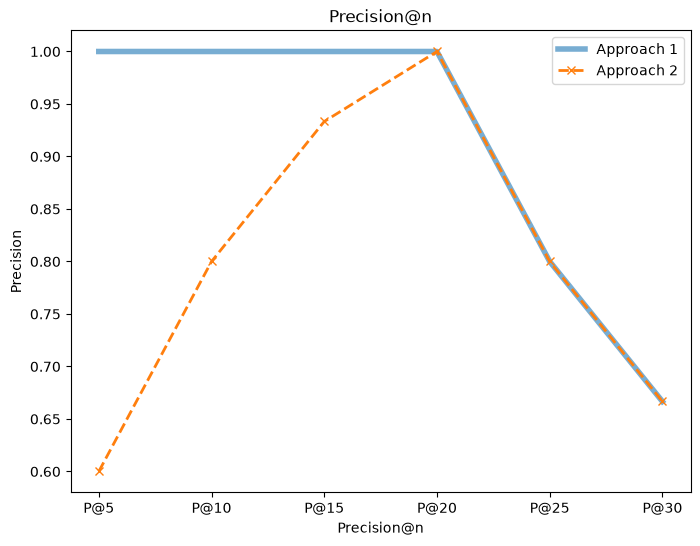

In [61]:
plt.figure(figsize=(8,6))
plt.plot(precision_stage, precision_at_stage_approach1, color='#1f77b4', linestyle='-', linewidth=4, alpha=0.6, label='Approach 1')
plt.plot(precision_stage, precision_at_stage_approach2, color='#ff7f0e', linestyle='--', linewidth=2, marker='x', label='Approach 2')
plt.legend()
plt.xticks(precision_stage, ['P@'+str(pre_stage) for pre_stage in precision_stage])
plt.title('Precision@n')
plt.xlabel('Precision@n')
plt.ylabel('Precision')
plt.show()

###### 3. Mean Average Precision(MAP) for Approach 1 (Sort) and Approach 2 (Term Frequency)

In [62]:
print('Mean Average Precision(MAP) for Approach 1 is %.2f'%(sum(precision_at_stage_approach1)/len(precision_at_stage_approach1)))
print('Mean Average Precision(MAP) for Approach 2 is %.2f'%(sum(precision_at_stage_approach2)/len(precision_at_stage_approach2)))

Mean Average Precision(MAP) for Approach 1 is 0.91
Mean Average Precision(MAP) for Approach 2 is 0.80
